<a href="https://colab.research.google.com/github/baliant/Thesis/blob/main/FourierTransformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [1]:
!git clone https://github.com/baliant/Thesis

Cloning into 'Thesis'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 106 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 7.36 MiB | 7.94 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [25]:
df_climate = pd.read_csv('Thesis/Data/climate_df_1995_2024.csv')
df_particle = pd.read_csv('Thesis/Data/pm_df_2021.csv')
df_syn = pd.read_csv('Thesis/Data/synthetic_time_series.csv')

df_climate['time'] = pd.to_datetime(df_climate['time'])
df_climate.set_index('time', inplace=True)

df_particle['time'] = pd.to_datetime(df_particle['time'])
df_particle.set_index('time', inplace=True)

df_syn['timestamp'] = pd.to_datetime(df_syn['timestamp'])
df_syn.set_index('timestamp', inplace=True)

print(df_climate.head())
print(df_particle.head())
print(df_syn.head())

              tg    hu   rr          pp
time                                   
1995-01-01  2.82  84.5  0.0   998.80000
1995-01-02  2.36  61.7  0.0  1005.10004
1995-01-03  0.51  73.9  0.0  1018.30000
1995-01-04 -0.96  69.0  0.0  1025.70010
1995-01-05 -0.05  69.3  0.0  1028.70010
                       lon    lat      pm2p5
time                                        
2021-01-01 00:00:00  18.95  47.25  26.125000
2021-01-01 01:00:00  18.95  47.25  25.257812
2021-01-01 02:00:00  18.95  47.25  23.117188
2021-01-01 03:00:00  18.95  47.25  20.835938
2021-01-01 04:00:00  18.95  47.25  20.914062
                     series_1_yearly  series_2_yearly_seasonal  \
timestamp                                                        
2023-01-01 00:00:00         0.049671                  0.012035   
2023-01-01 01:00:00        -0.013009                  0.073724   
2023-01-01 02:00:00         0.066403                 -0.082503   
2023-01-01 03:00:00         0.154755                  0.174585   
2023-01-0

In [24]:
def plot_periodogram(df, columns_to_plot, normalization_type='log'):
    """Plotting periodogram"""
    # Ensure df.index is a DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a pd.DatetimeIndex.")

    periods = [1, 7, 30, 100, 365]
    labels = ['Daily', 'Weekly', 'Monthly', 'Seasonly', 'Yearly']

    fig, ax = plt.subplots(figsize=(20, 6))
    for col, color, label in columns_to_plot:
        fft_values = np.fft.rfft(df[col])[1:]
        periodogram = np.abs(fft_values)**2 / len(df)


        if normalization_type == 'max':
            periodogram = periodogram / np.max(periodogram)
        elif normalization_type == 'log':
            periodogram = np.log10(periodogram + 1)
        elif normalization_type == 'z-score':
            periodogram = (periodogram - np.mean(periodogram)) / np.std(periodogram)
        elif normalization_type == 'percentile':
            percentile = np.percentile(periodogram, 95)
            periodogram = np.minimum(periodogram, percentile)



        freqs = np.fft.rfftfreq(len(df), d=1)[1:]
        daily_freq = 1 / 1
        daily_freq_index = np.argmin(np.abs(freqs - daily_freq))
        print("Daily frequency index:", daily_freq_index, "Frequency:", freqs[daily_freq_index])





        periods_freqs = 1 / freqs
        ax.plot(periods_freqs, periodogram, color=color, label=label)

    # Adjusting plot scales and labels
    ax.set_xscale("log")
    ax.set_xticks(periods)
    ax.set_xticklabels(labels, rotation=45)



    ax.set_title("Periodogram Analysis")
    ax.set_xlabel("Period (Days)")
    ax.set_ylabel("Spectral Power")
    ax.legend()
    plt.grid(True)
    plt.show()

Daily frequency index: 5386 Frequency: 0.5


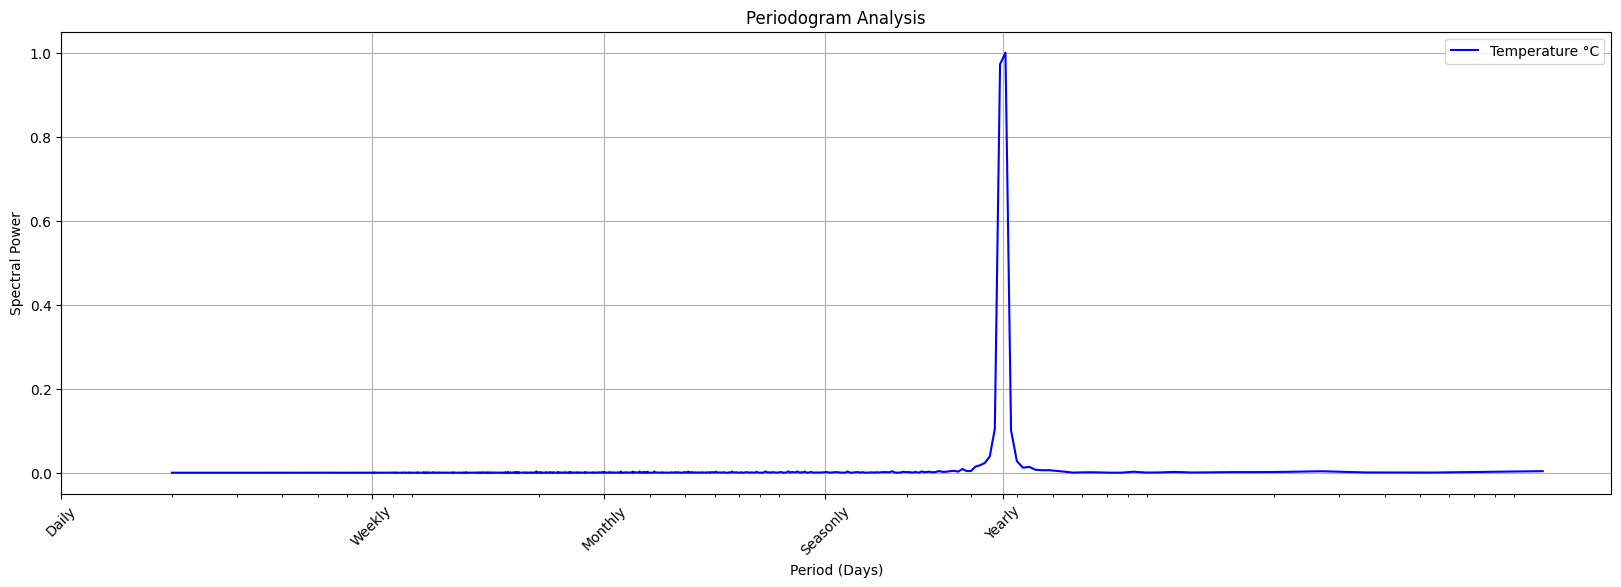

In [20]:
columns_to_plot = [('tg', 'blue', 'Temperature °C')]
plot_periodogram(df_climate, columns_to_plot, normalization_type='max')

Daily frequency index: 4379 Frequency: 0.5


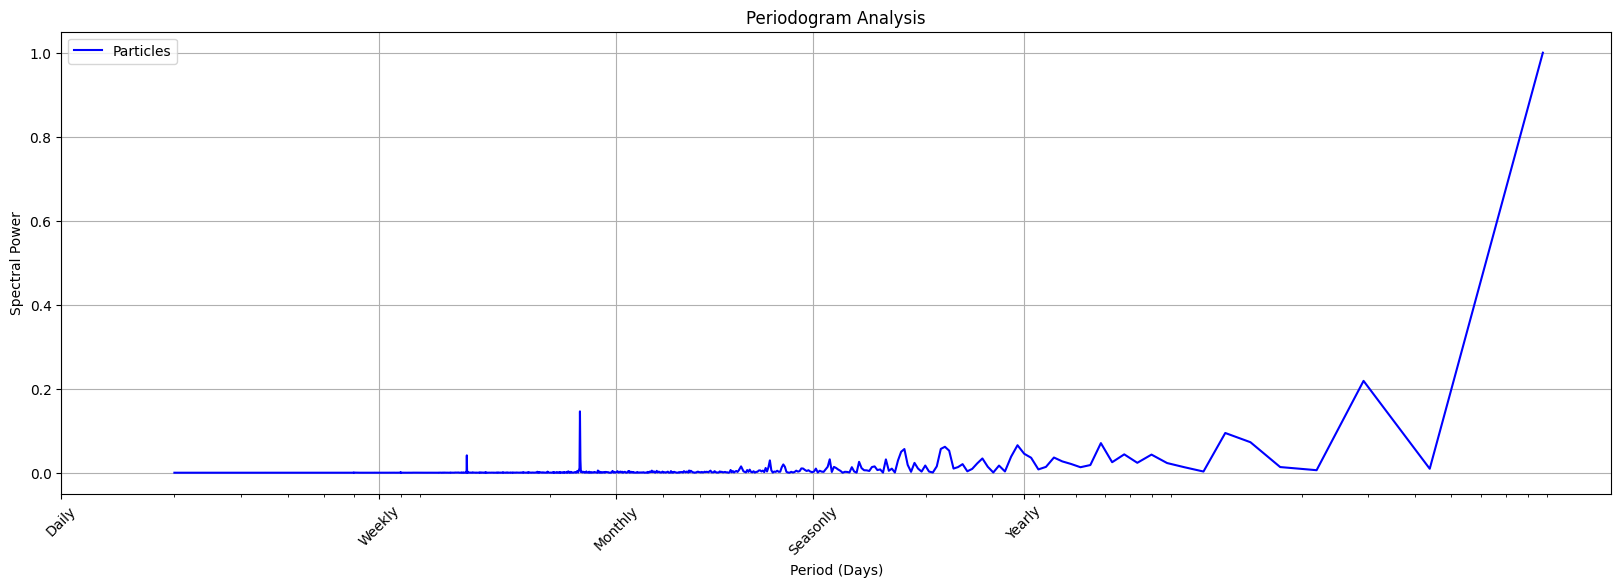

In [27]:
columns_to_plot = [('pm2p5', 'blue', 'Particles')]
plot_periodogram(df_particle, columns_to_plot, normalization_type='max')

Daily frequency index: 8759 Frequency: 0.5


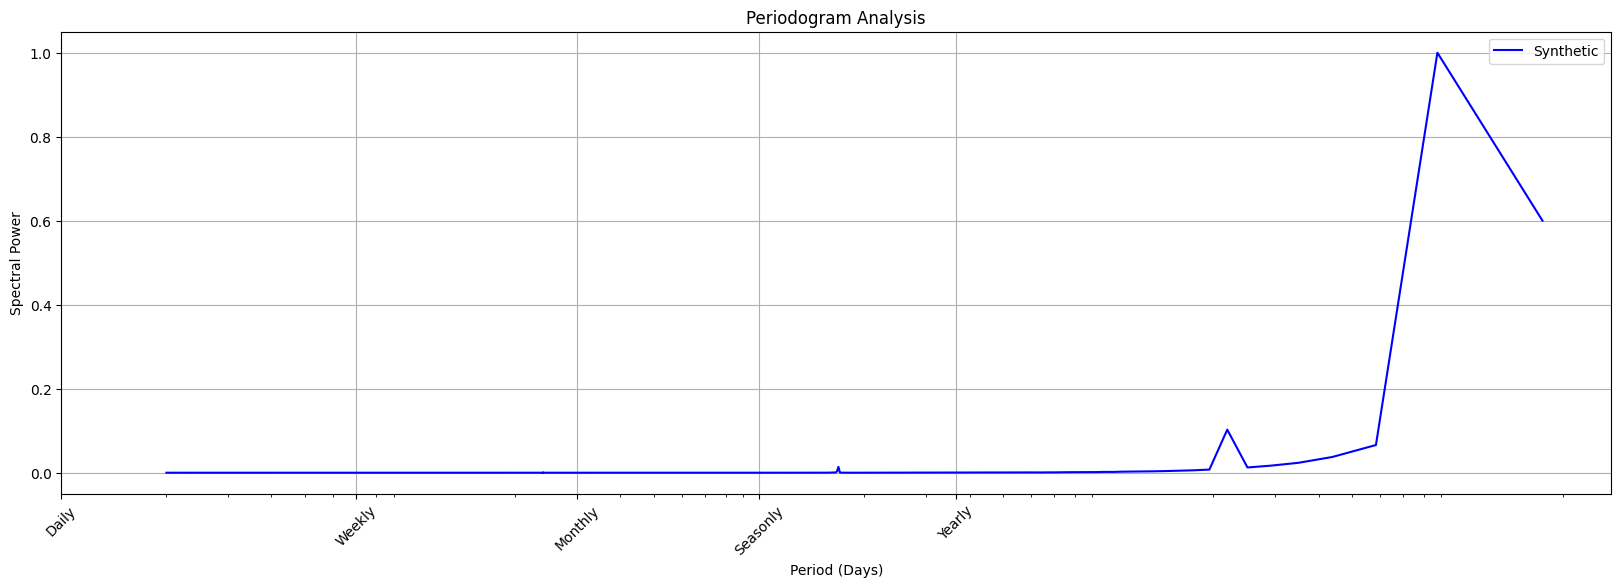

In [26]:
columns_to_plot = [('series_4_yearly_seasonal_weekly_daily', 'blue', 'Synthetic')]
plot_periodogram(df_syn, columns_to_plot, normalization_type='max')